## **CREDIT BEHAVIOUR ANALYSIS AND RISK ASSESSMENT**

**STAGE 1:- UNDERSTANDING THE DATA**

*Q1: VALIDATE CLIENT COVERAGE ACROSS ALL DATASETS*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
base_file=pd.read_csv(r"C:\Users\sonali\Downloads\base_file.csv")
enquiry_data=pd.read_csv(r"C:\Users\sonali\Downloads\enquiry_data.csv")
tradeline_data=pd.read_csv(r"C:\Users\sonali\Downloads\tradeline_data.csv")

Lets check the datasets

In [3]:
base_file

,Client_ID,Applied,Approved
0,101674,1.0,1
1,111523,3.0,0
2,123287,0.0,0
3,105413,3.0,1
4,119496,0.0,0
...,...,...,...
24795,107935,0.0,0
24796,114634,3.0,3
24797,121642,2.0,1
24798,106295,3.0,0


In [4]:
enquiry_data

,Client_ID,Total_Enquiry_6m_In,Total_Enquiry_1y_In,Total_Enquiry_2y_In
0,102623,NaN,12,32
1,119495,0.0,14,24
2,109833,1.0,5,18
3,118279,1.0,24,27
4,112417,9.0,9,16
...,...,...,...,...
24495,115548,7.0,17,32
24496,117675,7.0,15,15
24497,101593,13.0,19,31
24498,102291,8.0,13,13


In [5]:
tradeline_data

,Client_ID,Total_Tradelines_6m_In,Total_Tradelines_1y_In,Total_Tradelines_2y_In,Max_Trade_3m_Out
0,117286,14.0,14,31,2551
1,112073,13.0,14,31,17528
2,106784,10.0,10,14,4054
3,116361,18.0,18,25,19434
4,106046,2.0,10,25,5276
...,...,...,...,...,...
24995,107814,5.0,12,38,7279
24996,116924,9.0,15,34,5194
24997,115201,17.0,17,28,3422
24998,124130,10.0,23,37,9200


Checking unique client ID in all datasets

In [7]:
print(f'Total Unique Clients in tradeline_data: {tradeline_data['Client_ID'].nunique()}')
print(f'Total Unique Clients in enquiry_data: {enquiry_data['Client_ID'].nunique()}')
print(f'Total Unique Clients in base_file: {base_file['Client_ID'].nunique()}')

Total Unique Clients in tradeline_data: 25000
Total Unique Clients in enquiry_data: 24500
Total Unique Clients in base_file: 24800


Identify clients present in tradeline_data but missing in base_file or enquiry_data.
Identify clients present in enquiry_data but missing in base_file.


In [17]:
missing_tradeline_base=tradeline_data[~tradeline_data['Client_ID'].isin(base_file['Client_ID'])]
print("Clients present in tradeline_data but missing in base_file: ",missing_tradeline_base['Client_ID'].nunique())

missing_tradeline_enquiry=tradeline_data[~tradeline_data['Client_ID'].isin(enquiry_data['Client_ID'])]
print("Clients present in tradeline_data but missing in enquiry_data: ",missing_tradeline_enquiry['Client_ID'].nunique())

missing_enquiry_base=enquiry_data[~enquiry_data['Client_ID'].isin(base_file['Client_ID'])]
print("Clients present in enquiry_data but missing in base_file:",missing_enquiry_base['Client_ID'].nunique())

all_clients=pd.concat([tradeline_data[['Client_ID']],enquiry_data[['Client_ID']],base_file[['Client_ID']]])['Client_ID'].nunique()

common_clients=len(
     set(tradeline_data['Client_ID'])
    .intersection(enquiry_data['Client_ID'])
    .intersection(base_file['Client_ID'])
)
missing_clients=all_clients-common_clients
print(f'Clients missing in at least one dataset: {missing_clients}')
percentage_missing=round((missing_clients / all_clients)*100,2)
print(f'Percentage of inconsistent clients: {percentage_missing}%')

Clients present in tradeline_data but missing in base_file:  200
Clients present in tradeline_data but missing in enquiry_data:  500
Clients present in enquiry_data but missing in base_file: 196
Clients missing in at least one dataset: 696
Percentage of inconsistent clients: 2.78%


*Q2: INVESTIGATE DUPLICATE CLIENT ENTRIES*

In [21]:
#---FIND DUPLICATES---
tradeline_duplicates=tradeline_data[
    tradeline_data.duplicated(subset='Client_ID',keep=False)]
enquiry_duplicates=enquiry_data[
    enquiry_data.duplicated(subset='Client_ID',keep=False)]
base_duplicates=base_file[
    base_file.duplicated(subset='Client_ID',keep=False)]

#----CHECK DIFFERENT VALUES IF EXIST IN DUPLICATES---
#--TRADELINE--
tradeline_diff=tradeline_duplicates.groupby('Client_ID')['Total_Tradelines_6m_In'].nunique()
tradeline_diff_clients=tradeline_diff[tradeline_diff>1]

#--ENQUIRY--
enquiry_diff=enquiry_duplicates.groupby('Client_ID')['Total_Enquiry_6m_In'].nunique()
enquiry_diff_clients=enquiry_diff[enquiry_diff>1]

#--BASE_FILE
base_diff=base_duplicates.groupby('Client_ID')['Applied'].nunique()
base_diff_clients=base_diff[base_diff>1]

print(f'Dataset: tradeline_data, Duplicate Clients:{tradeline_duplicates['Client_ID'].nunique()}, Case with different values: {len(tradeline_diff_clients)}')
print(f'Dataset: enquiry_data, Duplicate Clients:{enquiry_duplicates['Client_ID'].nunique()}, Case with different values: {len(enquiry_diff_clients)}')
print(f'Dataset: base_file, Duplicate Clients:{base_duplicates['Client_ID'].nunique()}, Case with different values: {len(base_diff_clients)}')

Dataset: tradeline_data, Duplicate Clients:0, Case with different values: 0
Dataset: enquiry_data, Duplicate Clients:0, Case with different values: 0
Dataset: base_file, Duplicate Clients:0, Case with different values: 0


*Q3: IDENTIFY CLIENTS WITH MISSING KEY DATA*

In [52]:
#---MISSING DATA IN tradeline_data---
missing_td=tradeline_data['Total_Tradelines_6m_In'].isna().sum()
total_td=len(tradeline_data)
diff_td=round(missing_td/total_td*100,2)
print('Missing Critical Data in tradeline_data:',diff_td,'%')

#---MISSING DATA IN tradeline_data---
missing_e=enquiry_data['Total_Enquiry_6m_In'].isna().sum()
total_e=len(enquiry_data)
diff_e=round(missing_e/total_e,2)
print('Missing Critical Data in enquiry_data:',diff_e,'%')

#---MISSING DATA IN BASE FILE---
missing_bap=base_file['Applied'].isna().sum()
missing_ba=base_file['Approved'].isna().sum()
total_b=len(base_file)
missing_b=missing_bap+missing_ba
diff_b=round(missing_b/total_b*100,2)
print('Missing Critical Data in base_file:',diff_b,"%")

Missing Critical Data in tradeline_data: 0.8 %
Missing Critical Data in enquiry_data: 0.01 %
Missing Critical Data in base_file: 0.2 %


*Q4: VALIDATE TRADELINE DATA CONSISTENCY OVER TIME*

In [54]:
condition=((tradeline_data['Total_Tradelines_6m_In']> tradeline_data['Total_Tradelines_1y_In'])
    &(tradeline_data['Total_Tradelines_1y_In']>tradeline_data['Total_Tradelines_2y_In']))
decreasing_clients=tradeline_data[condition]
decreasing_client_count=decreasing_clients['Client_ID'].nunique()
total_clients=tradeline_data['Client_ID'].nunique()
decreasing_percentage=round((decreasing_client_count / total_clients) * 100,2)
print(f'Clients with decreasing Tradelines: {decreasing_client_count}')
print(f'Percentage of inconsistent clients: {decreasing_percentage}')

Clients with decreasing Tradelines: 0
Percentage of inconsistent clients: 0.0


*Q5: VALIDATE ENQUIRY DATA CONSISTENCY OVER TIME*

In [56]:
condition=((enquiry_data['Total_Enquiry_6m_In']> enquiry_data['Total_Enquiry_1y_In'])
    &(enquiry_data['Total_Enquiry_1y_In']>enquiry_data['Total_Enquiry_2y_In']))
decreasing_clients=enquiry_data[condition]
decreasing_client_count=decreasing_clients['Client_ID'].nunique()
total_clients=enquiry_data['Client_ID'].nunique()
decreasing_percentage=round((decreasing_client_count / total_clients) * 100,2)
print(f'Clients with decreasing Enquiries: {decreasing_client_count}')
print(f'Percentage of inconsistent clients: {decreasing_percentage}')

Clients with decreasing Enquiries: 0
Percentage of inconsistent clients: 0.0


*Q6: Detect Outliers in Tradeline Counts.*

In [61]:
Q1=tradeline_data['Total_Tradelines_6m_In'].quantile(0.25)
Q2=tradeline_data['Total_Tradelines_6m_In'].quantile(0.50)
Q3=tradeline_data['Total_Tradelines_6m_In'].quantile(0.75)
IQR=Q3-Q1
upper_bound=Q3+1.5*IQR
outliers=tradeline_data[tradeline_data['Total_Tradelines_6m_In']>upper_bound]
outlier_count=outliers['Client_ID'].nunique()
print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound:{upper_bound}')
print(f'Clients Exceeding threshold: {outlier_count}')

Q1: 5.0, Q3: 14.0, IQR: 9.0, Upper Bound:27.5
Clients Exceeding threshold: 0


*Q7: Ensure Loan Approval Does Not Exceed Applications*

In [63]:
condition=(base_file['Applied']<base_file['Approved'])
wrong=base_file[condition]
wrong_count=len(wrong)
total_count=len(base_file)
perc=round(wrong_count/total_count*100,2)
print(f'Clients with Approved>Applied: {wrong_count}')
print(f'Percentage: {perc}')

Clients with Approved>Applied: 0
Percentage: 0.0


*Q8: Check Unique Value Distribution for Key Categorical Columns.*

In [64]:
unique_applied=base_file['Applied'].unique()
unique_approved=base_file['Approved'].unique()
print(f'Unique Values in Applied: {unique_applied}')
print(f'Unique Values in Approved: {unique_approved}')

Unique Values in Applied: [ 1.  3.  0.  4.  2. nan]
Unique Values in Approved: [1 0 2 3 4]


**STAGE 2:- DATA CLEANING**

*Q1: Handle Missing Values in Critical Columns.*

In [76]:
#---FILL MISSING VALUES FOR TRADELINES DATA WITH MEDIAN---
q2_tradeline=tradeline_data['Total_Tradelines_6m_In'].quantile(0.50)
tradeline_data['Total_Tradelines_6m_In']=tradeline_data['Total_Tradelines_6m_In'].fillna(q2_tradeline)

#---FILL MISSING VALUES FOR ENQUIRY DATA WITH MEDIAN---
q2_enquiry=enquiry_data['Total_Enquiry_6m_In'].quantile(0.50)
enquiry_data['Total_Enquiry_6m_In']=enquiry_data['Total_Enquiry_6m_In'].fillna(q2_enquiry)

#--FILL MISSING VALUES FOR APPLIED AND APPROVED---
base_file.loc[(base_file['Applied'].isna())&(base_file['Approved'].notna()),'Applied']=base_file['Approved']

# -----------------------------------------
# Remove rows where both are missing
# -----------------------------------------
base_file=base_file.dropna(subset=['Applied','Approved'],how='all')
print('Missing Values in Total_Tradelines_6m_In:',tradeline_data['Total_Tradelines_6m_In'].isna().sum())
print('Missing Values in Total_Enquiry_6m_In:',enquiry_data['Total_Enquiry_6m_In'].isna().sum())
print('Missing Values in Applied:',base_file['Applied'].isna().sum())
print('Missing Values in Approved:',base_file['Approved'].isna().sum())

Missing Values in Total_Tradelines_6m_In: 0
Missing Values in Total_Enquiry_6m_In: 0
Missing Values in Applied: 0
Missing Values in Approved: 0


*Q2: Standardize Data Types for Numeric Columns.*

In [87]:
print(tradeline_data.dtypes)
print(enquiry_data.dtypes)
print(base_file.dtypes)

Client_ID                 int64
Total_Tradelines_6m_In    int64
Total_Tradelines_1y_In    int64
Total_Tradelines_2y_In    int64
Max_Trade_3m_Out          int64
dtype: object
Client_ID              int64
Total_Enquiry_6m_In    int64
Total_Enquiry_1y_In    int64
Total_Enquiry_2y_In    int64
dtype: object
Client_ID      int64
Applied      float64
Approved       int64
dtype: object


In [88]:
neg_value=tradeline_data[tradeline_data['Total_Tradelines_6m_In']<0]
print(neg_value)

Empty DataFrame
Columns: [Client_ID, Total_Tradelines_6m_In, Total_Tradelines_1y_In, Total_Tradelines_2y_In, Max_Trade_3m_Out]
Index: []


**NO NEGATIVE VALUES FOUND**

*Q: Apply Winsorization to Remove Extreme Outliers.*

In [93]:
tradeline_99=tradeline_data['Total_Tradelines_6m_In'].quantile(0.99)
enquiry_99=enquiry_data['Total_Enquiry_6m_In'].quantile(0.99)
print('99th percentile for Total_Tradelines_6m_In is: ',trade_99)
print('99th percentile for Total_Enquiry_6m_In is: ',enquiry_99)

#---CAP ALL VALUES ABOUVE 99TH PERCENTILE---
tradeline_data['Total_Tradelines_6m_In']=(tradeline_data['Total_Tradelines_6m_In'].clip(upper=tradeline_99))
enquiry_data['Total_Enquiry_6m_In']=(enquiry_data['Total_Enquiry_6m_In'].clip(upper=enquiry_99))

99th percentile for Total_Tradelines_6m_In is:  19.0
99th percentile for Total_Enquiry_6m_In is:  14.0


**Stage 3. Data Analysis - Univariate Questions**

*Q1: Analyze the Distribution of Total_Tradelines_6m_In.*


Skewness: -0.0
Mean=9.49164, Median=10.0, Std_dev=5.72036004209195


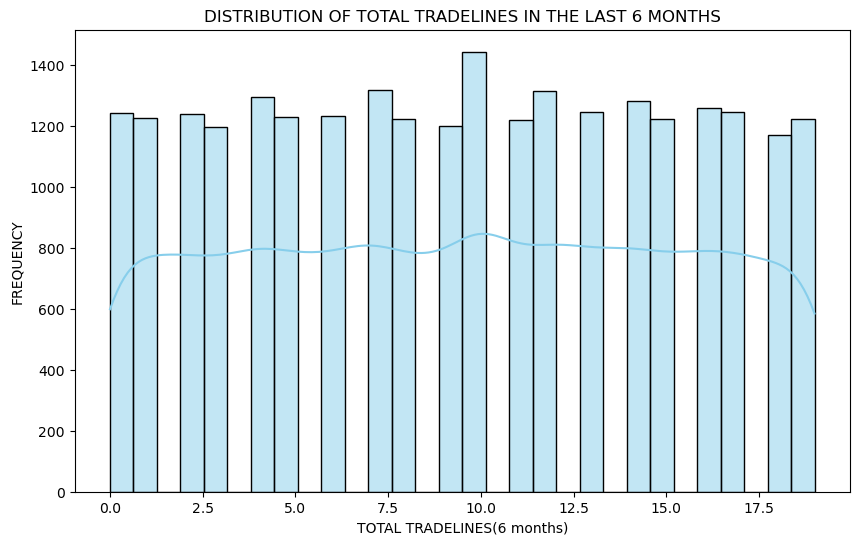

In [102]:
mean_val=tradeline_data['Total_Tradelines_6m_In'].mean()
median_val=tradeline_data['Total_Tradelines_6m_In'].median()
std_val=tradeline_data['Total_Tradelines_6m_In'].std()
skewness = tradeline_data['Total_Tradelines_6m_In'].skew()
print("\nSkewness:", round(skewness, 2))

#---PLOT HISTOGRAM---
plt.figure(figsize=(10,6))
sns.histplot(
    tradeline_data['Total_Tradelines_6m_In'],
    bins=30,
    kde=True,
    color='skyblue',
    edgecolor='black',
)

plt.title('DISTRIBUTION OF TOTAL TRADELINES IN THE LAST 6 MONTHS')
plt.xlabel('TOTAL TRADELINES(6 months)')
plt.ylabel('FREQUENCY')

print(f'Mean={mean_val}, Median={median_val}, Std_dev={std_val}')

*Q2: Analyze the Distribution of Total_Enquiry_6m_In.*


Skewness: -0.01
Mean=7.043877551020408, Median=7.0, Std_dev=4.31548921283715


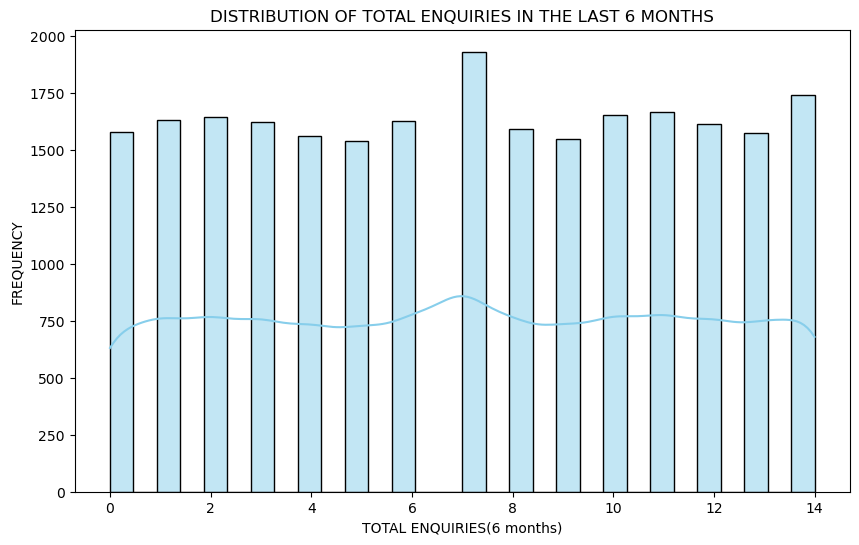

In [104]:
mean_val=enquiry_data['Total_Enquiry_6m_In'].mean()
median_val=enquiry_data['Total_Enquiry_6m_In'].median()
std_val=enquiry_data['Total_Enquiry_6m_In'].std()
skewness=enquiry_data['Total_Enquiry_6m_In'].skew()
print("\nSkewness:", round(skewness, 2))

#---PLOT HISTOGRAM---
plt.figure(figsize=(10,6))
sns.histplot(
    enquiry_data['Total_Enquiry_6m_In'],
    bins=30,
    kde=True,
    color='skyblue',
    edgecolor='black',
)

plt.title('DISTRIBUTION OF TOTAL ENQUIRIES IN THE LAST 6 MONTHS')
plt.xlabel('TOTAL ENQUIRIES(6 months)')
plt.ylabel('FREQUENCY')

print(f'Mean={mean_val}, Median={median_val}, Std_dev={std_val}')

*Q3: Distribution of Loan Applications (Applied).*

In [110]:
applied_loan=base_file[base_file['Applied']>0]['Applied'].count()
applied_lp=round(applied_loan/len(base_file['Applied'])*100,2)
print(f'Percentage of clients who applied: {applied_lp}%')
print(f'Percentage of clients who did not apply: {round(100-applied_lp,2)}%')

Percentage of clients who applied: 79.7%
Percentage of clients who did not apply: 20.3%


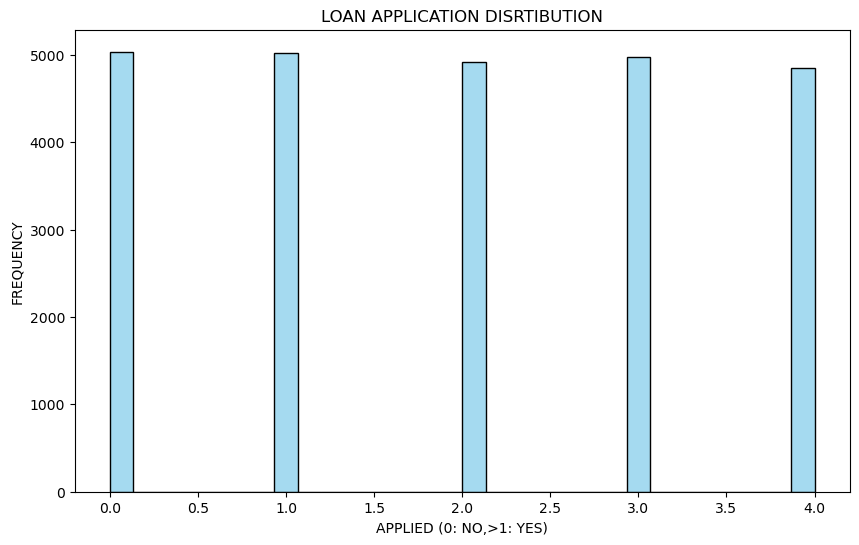

In [117]:
#---PLOT HISTOGRAM---
plt.figure(figsize=(10,6))
sns.histplot(
    base_file['Applied'],
    color='skyblue',
    edgecolor='black',
)
plt.title('LOAN APPLICATION DISRTIBUTION')
plt.xlabel('APPLIED (0: NO,>1: YES)')
plt.ylabel('FREQUENCY')
plt.show()

*Q4: Analyze the Loan Approval Rate*

In [116]:
approved_loan=base_file[base_file['Approved']>0]['Approved'].count()
approval_rate=round(approved_loan/applied_loan,2)
print(f'Loan Approval Rate: {approval_rate}')

Loan Approval Rate: 0.8


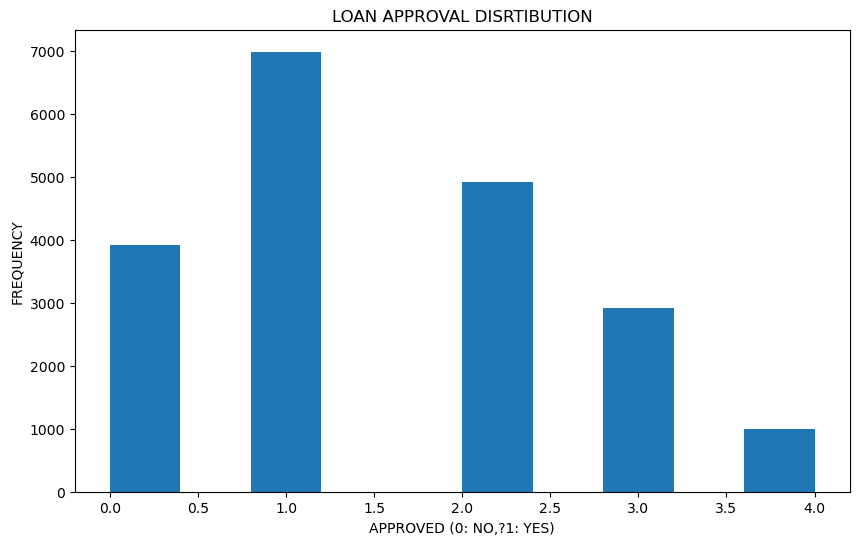

In [119]:
applied=base_file[base_file['Applied']>0]
#---PLOT HISTOGRAM---
plt.figure(figsize=(10,6))
plt.hist(applied['Approved'])
plt.title('LOAN APPROVAL DISRTIBUTION')
plt.xlabel('APPROVED (0: NO,?1: YES)')
plt.ylabel('FREQUENCY')
plt.show()

*Q5: Examine the Distribution of Max_Trade_3m_Out*

Mean=10471.49164, Median=10429.0, Std_dev=5498.743149376866


Text(0, 0.5, 'FREQUENCY')

<Figure size 1000x600 with 0 Axes>

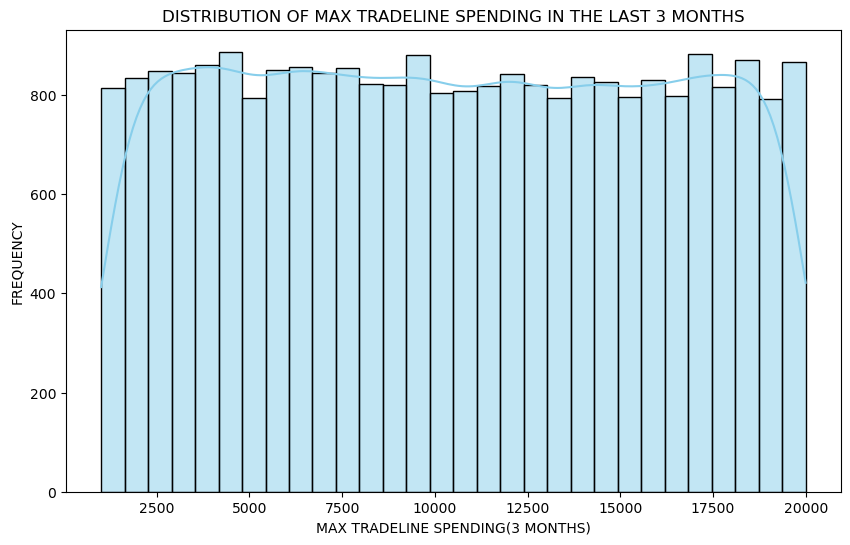

In [122]:
mean_val=tradeline_data['Max_Trade_3m_Out'].mean()
median_val=tradeline_data['Max_Trade_3m_Out'].median()
std_val=tradeline_data['Max_Trade_3m_Out'].std()
print(f'Mean={mean_val}, Median={median_val}, Std_dev={std_val}')

#---PLOT HISTOGRAM---
plt.figure(figsize=(10,6))
plt.figure(figsize=(10,6))
sns.histplot(
    tradeline_data['Max_Trade_3m_Out'],
    bins=30,
    kde=True,
    color='skyblue',
    edgecolor='black',
)

plt.title('DISTRIBUTION OF MAX TRADELINE SPENDING IN THE LAST 3 MONTHS')
plt.xlabel('MAX TRADELINE SPENDING(3 MONTHS)')
plt.ylabel('FREQUENCY')

*Q6: Identify the Spread of Total_Tradelines_1y_In.*

In [126]:
print(tradeline_data['Total_Tradelines_1y_In'].describe())

count    25000.000000
mean        18.130320
std          6.279251
min          5.000000
25%         13.000000
50%         18.000000
75%         23.000000
max         29.000000
Name: Total_Tradelines_1y_In, dtype: float64


Text(0, 0.5, 'FREQUENCY')

<Figure size 1000x600 with 0 Axes>

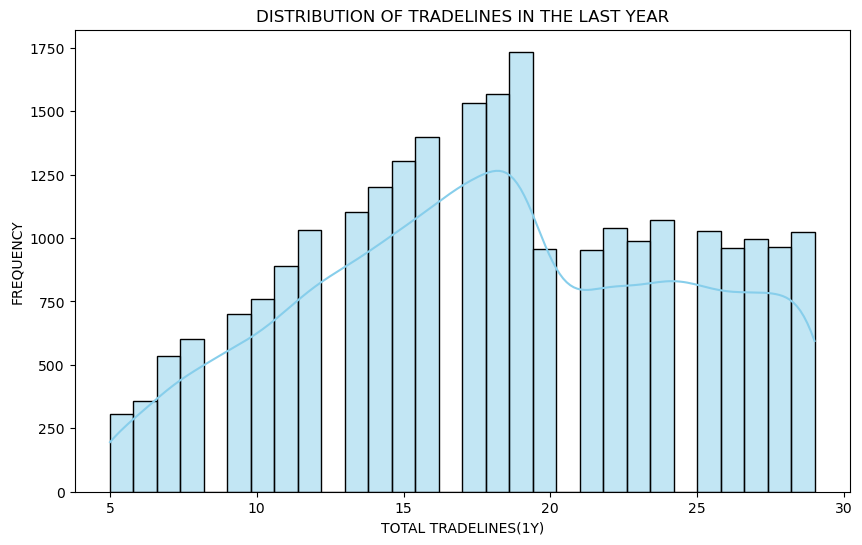

In [127]:
#---PLOT HISTOGRAM---
plt.figure(figsize=(10,6))
plt.figure(figsize=(10,6))
sns.histplot(
    tradeline_data['Total_Tradelines_1y_In'],
    bins=30,
    kde=True,
    color='skyblue',
    edgecolor='black',
)
plt.title('DISTRIBUTION OF TRADELINES IN THE LAST YEAR')
plt.xlabel('TOTAL TRADELINES(1Y)')
plt.ylabel('FREQUENCY')

*Q7: Distribution of Total_Enquiry_1y_In.*

Text(0, 0.5, 'FREQUENCY')

<Figure size 1000x600 with 0 Axes>

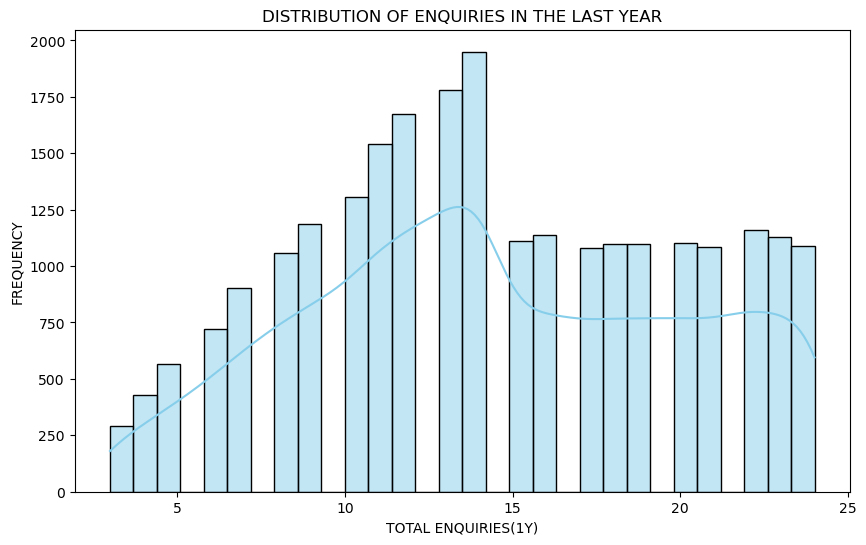

In [128]:
#---PLOT HISTOGRAM---
plt.figure(figsize=(10,6))
plt.figure(figsize=(10,6))
sns.histplot(
    enquiry_data['Total_Enquiry_1y_In'],
    bins=30,
    kde=True,
    color='skyblue',
    edgecolor='black',
)
plt.title('DISTRIBUTION OF ENQUIRIES IN THE LAST YEAR')
plt.xlabel('TOTAL ENQUIRIES(1Y)')
plt.ylabel('FREQUENCY')

**Stage 4. Data Exploration and Bivariate Analysis**

*Q1: Investigating Credit Behavior: Does Higher Credit Activity Lead to More
Enquiries?*

Correlation: 0.01


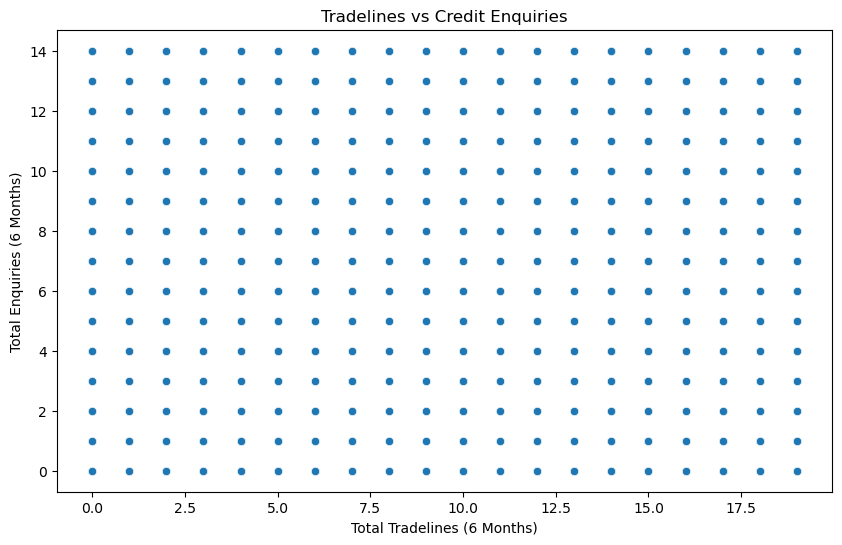


Positive correlation detected.
Clients with higher credit activity tend to make more credit enquiries.


In [139]:
merged=tradeline_data.merge(enquiry_data,on=['Client_ID'],how='inner')
correlation=merged['Total_Tradelines_6m_In'].corr(merged['Total_Enquiry_6m_In'])

print("Correlation:",round(correlation, 2))

#---PLOTING CORRELATION---
plt.figure(figsize=(10,6))
sns.scatterplot(data=merged,x='Total_Tradelines_6m_In',y='Total_Enquiry_6m_In')
plt.title('Tradelines vs Credit Enquiries')
plt.xlabel('Total Tradelines (6 Months)')
plt.ylabel('Total Enquiries (6 Months)')
plt.show()

#-- INTERPRETATION--
if correlation>0:
    print("\nPositive correlation detected.")
    print("Clients with higher credit activity tend to make more credit enquiries.")
elif correlation<0:
    print("\nNegative correlation detected.")
    print("Higher tradelines are associated with fewer credit enquiries.")
else:
    print("\nNo significant relationship detected.")

*Q2: Exploring Loan Application Behavior: Do Clients with More Tradelines Apply
More for Loans?*

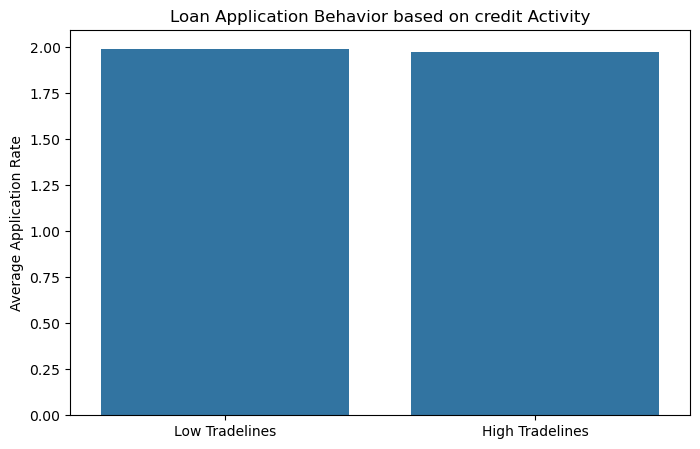

Average application rate for clients with more tradelines: 1.97
Average application rate for clients with less tradelines: 1.99


In [143]:
merged_data=tradeline_data.merge(base_file,on=['Client_ID'],how='inner')
median_tradeline=merged_data['Total_Tradelines_6m_In'].median()
high_data=merged_data[merged_data['Total_Tradelines_6m_In']>median_tradeline]['Applied'].mean()
low_data=merged_data[merged_data['Total_Tradelines_6m_In']<median_tradeline]['Applied'].mean()

#---PLOT A BAR CHART---
categories=['Low Tradelines', 'High Tradelines']
values=[low_data, high_data]
plt.figure(figsize=(8,5))
sns.barplot(
    x=categories,
    y=values
)
plt.title('Loan Application Behavior based on credit Activity')
plt.ylabel('Average Application Rate')
plt.show()
print(f'Average application rate for clients with more tradelines: {round(high_data,2)}')
print(f'Average application rate for clients with less tradelines: {round(low_data,2)}')

*Q3: Understanding Loan Approvals: Does Higher Spending Lead to More Approvals?*

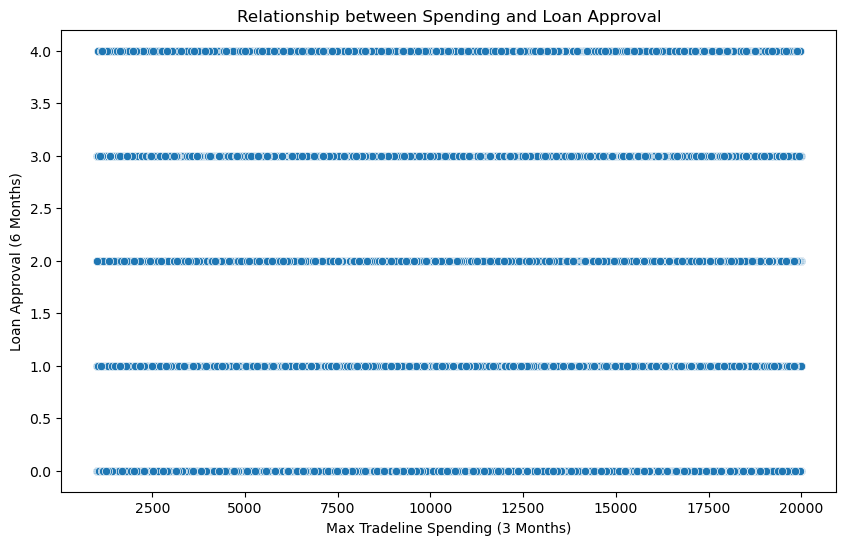

Correlation between Spending and Loan Approval: -0.0


In [145]:
merged_app=base_file.merge(tradeline_data,on='Client_ID',how='inner')
merged_a=merged_app[merged_app['Applied']>0]
corr_a=merged_a['Max_Trade_3m_Out'].corr(merged_a['Approved'])

#---PLOT A SCATTER PLOT---
plt.figure(figsize=(10,6))
sns.scatterplot(data=merged_a,x='Max_Trade_3m_Out',y='Approved')
plt.title('Relationship between Spending and Loan Approval')
plt.xlabel('Max Tradeline Spending (3 Months)')
plt.ylabel('Loan Approval (6 Months)')
plt.show()

print(f'Correlation between Spending and Loan Approval: {round(corr_a,2)}')

*Q4: Analyzing Loan Approvals: Are Clients with More Applications More Likely to Be
Approved?*

**Stage 5. Feature Engineering**

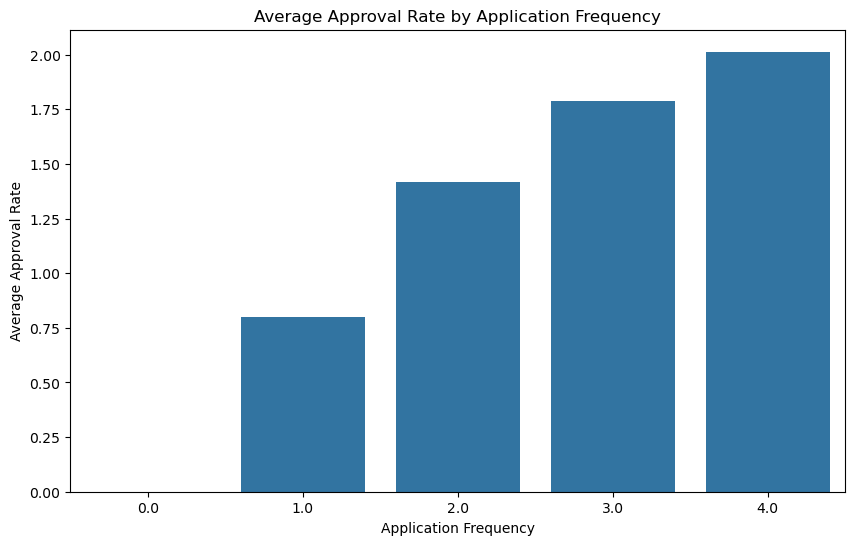


Average Approval Rate by Application Frequency:

   Application_Frequency  Approved
0                    0.0  0.000000
1                    1.0  0.799960
2                    2.0  1.415497
3                    3.0  1.786318
4                    4.0  2.013803


In [150]:
application_frequency=(base_file.groupby('Client_ID')['Applied'].mean().reset_index(name='Application_Frequency'))
merged_data=application_frequency.merge(base_file[['Client_ID', 'Approved']],on='Client_ID',how='inner')
approval_analysis=(
    merged_data
    .groupby('Application_Frequency')['Approved']
    .mean()
    .reset_index())

#---PLOT CHART---
plt.figure(figsize=(10,6))
sns.barplot(
    data=approval_analysis,
    x='Application_Frequency',
    y='Approved')
plt.title('Average Approval Rate by Application Frequency')
plt.xlabel('Application Frequency')
plt.ylabel('Average Approval Rate')
plt.show()

print("\nAverage Approval Rate by Application Frequency:\n")
print(approval_analysis)

*Q1: Assessing the Loan Approval Process: Exploring the Loan Approval Rate.*

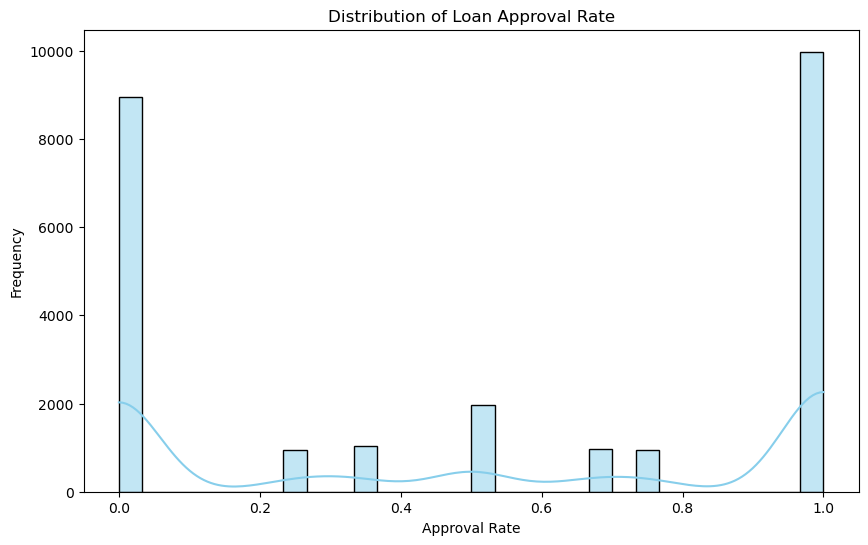

Mean Approval Rate: 0.52


In [129]:
base_file['Approval_Rate']=(base_file['Approved']/base_file['Applied'])
base_file['Approval_Rate'] = (base_file['Approval_Rate'].replace([np.inf, -np.inf, np.nan],0))
plt.figure(figsize=(10,6))
sns.histplot(
    base_file['Approval_Rate'],
    bins=30,
    kde=True,
    color='skyblue',
    edgecolor='black')
plt.title('Distribution of Loan Approval Rate')
plt.xlabel('Approval Rate')
plt.ylabel('Frequency')
plt.show()

#---MEAN APPROVAL RATE---
mean_approval_rate=round(base_file['Approval_Rate'].mean(),2)
print("Mean Approval Rate:",mean_approval_rate)

*Q2: Understanding Credit Utilization: Evaluating How Clients Use Their Credit.*

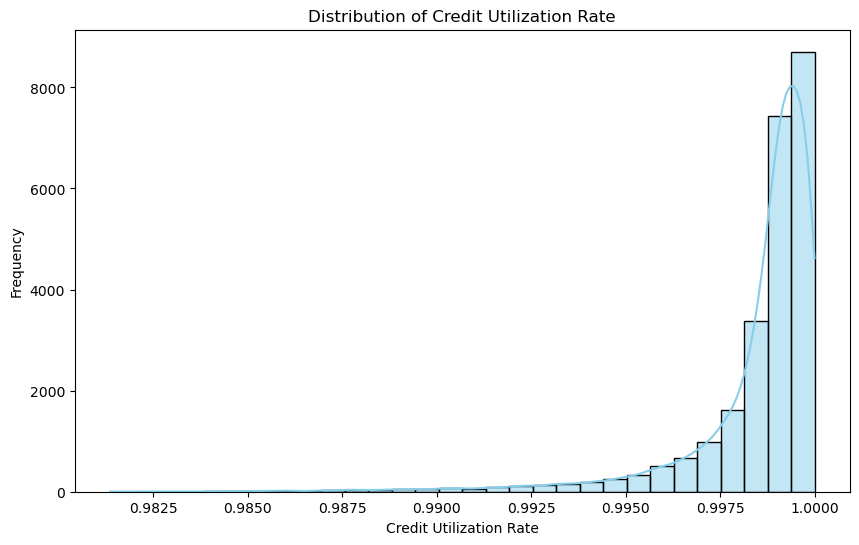

Average Credit Utilization Rate: 1.0


In [151]:
#---CREDIT UTILISATION RATE---
tradeline_data['Credit_Utilization_Rate']=(tradeline_data['Max_Trade_3m_Out']/
    (tradeline_data['Total_Tradelines_6m_In']+tradeline_data['Max_Trade_3m_Out']))
tradeline_data['Credit_Utilization_Rate']=(tradeline_data['Credit_Utilization_Rate'].replace([np.inf, -np.inf, np.nan], 0))
plt.figure(figsize=(10,6))
sns.histplot(
    tradeline_data['Credit_Utilization_Rate'],
    bins=30,
    kde=True,
    color='skyblue',
    edgecolor='black'
)
plt.title('Distribution of Credit Utilization Rate')
plt.xlabel('Credit Utilization Rate')
plt.ylabel('Frequency')
plt.show()

#--AVERAGE CREDIT UTILISATION RATE--
avg_utilization=round(tradeline_data['Credit_Utilization_Rate'].mean(),2)
print("Average Credit Utilization Rate:",avg_utilization)

*Q3: Segmenting Clients Based on Credit Activity.*

    Activity_Group  Client_Count
0  Medium Activity         12689
1     Low Activity          7419
2    High Activity          4892


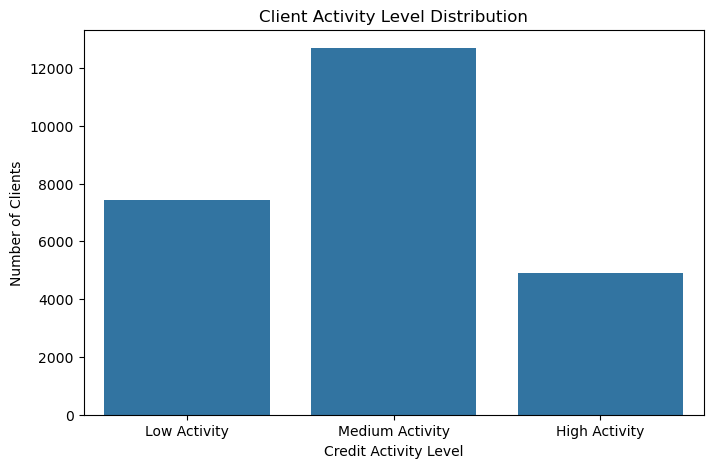

In [153]:
def classify_activity(x):
    if 0<=x<=5:
        return 'Low Activity'
    elif 6<=x<= 15:
        return 'Medium Activity'
    else:
        return 'High Activity'


tradeline_data['Activity_Group']=(tradeline_data['Total_Tradelines_6m_In'].apply(classify_activity))
segment_counts=(tradeline_data['Activity_Group'].value_counts().reset_index())
segment_counts.columns=['Activity_Group','Client_Count']
print(segment_counts)

#---Count Plot---
plt.figure(figsize=(8,5))
sns.countplot(
    data=tradeline_data,
    x='Activity_Group',
    order=[
        'Low Activity',
        'Medium Activity',
        'High Activity'
    ])
plt.title('Client Activity Level Distribution')
plt.xlabel('Credit Activity Level')
plt.ylabel('Number of Clients')
plt.show()

**Stage 6. Advanced Analysis**

*Q1: Identify High-Risk Clients Based on Credit Behavior and Spending.*

    Risk_Level  Approval_Rate
0    High Risk           0.52
1     Low Risk           0.52
2  Medium Risk           0.53


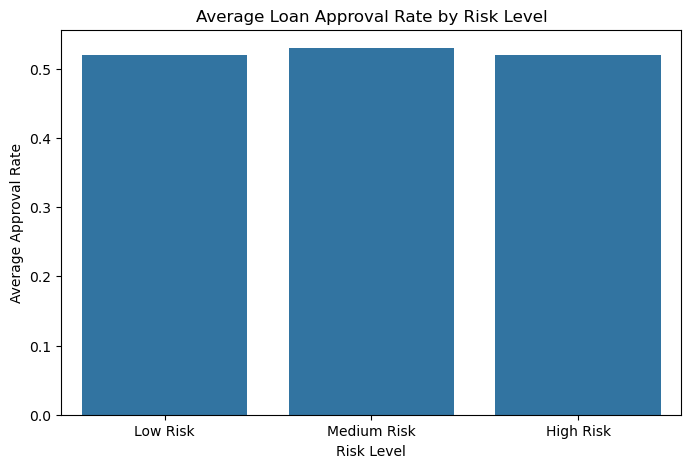

In [155]:
merged_data = tradeline_data.merge(
    base_file,
    on='Client_ID',
    how='inner'
)
#---CREATE RISK PROFILE---
def risk_profile(row):
    if (
        row['Total_Tradelines_6m_In'] > 10
        and
        row['Max_Trade_3m_Out'] > 5000
    ):
        return 'High Risk'

    elif (
        5 <= row['Total_Tradelines_6m_In'] <= 10
        and
        2000 <= row['Max_Trade_3m_Out'] <= 5000
    ):
        return 'Medium Risk'

    else:
        return 'Low Risk'

merged_data['Risk_Level'] = (
    merged_data.apply(risk_profile, axis=1)
)

#--LOAN APPROVAL RATE--
merged_data['Approval_Rate'] = (
    merged_data['Approved']
    /
    merged_data['Applied']
)
#--Handle invalid values--
merged_data['Approval_Rate'] = (
    merged_data['Approval_Rate']
    .replace([float('inf'), -float('inf')], 0)
    .fillna(0)
)

#--Average Approval Rate by Risk Level--
approval_by_risk = (
    merged_data
    .groupby('Risk_Level')['Approval_Rate']
    .mean()
    .reset_index()
)

approval_by_risk['Approval_Rate'] = (
    approval_by_risk['Approval_Rate']
    .round(2)
)
print(approval_by_risk)

#---Bar Plot---
plt.figure(figsize=(8,5))
sns.barplot(
    data=approval_by_risk,
    x='Risk_Level',
    y='Approval_Rate',
    order=['Low Risk', 'Medium Risk', 'High Risk']
)
plt.title( 'Average Loan Approval Rate by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Average Approval Rate')
plt.show()

*Q2:Explore the Impact of Spending Behavior on Loan Approval.*

    Spending_Group  Approval_Rate
0    High Spending           0.52
1     Low Spending           0.56
2  Medium Spending           0.52


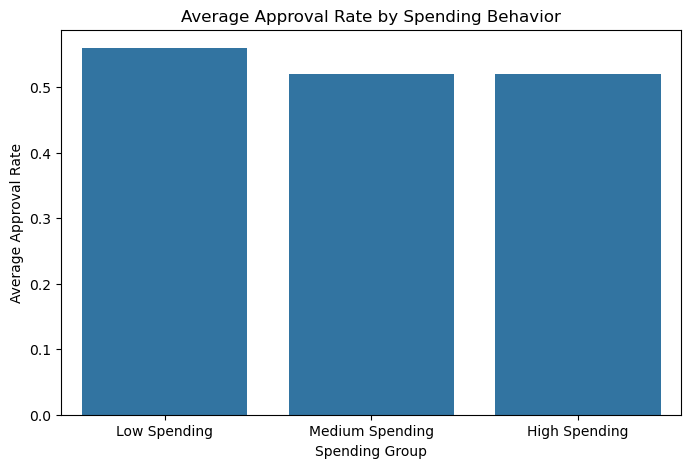

In [156]:
merged_data = tradeline_data.merge(
    base_file,
    on='Client_ID',
    how='inner'
)
def spending_group(x):
    if x <= 2000:
        return 'Low Spending'

    elif 2000 < x <= 5000:
        return 'Medium Spending'

    else:
        return 'High Spending'

merged_data['Spending_Group']=(
    merged_data['Max_Trade_3m_Out']
    .apply(spending_group)
)
merged_data['Approval_Rate'] = (
    merged_data['Approved']/merged_data['Applied']
)

# Handle invalid values
merged_data['Approval_Rate'] = (
    merged_data['Approval_Rate']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)
#--Average Approval Rate by Spending Group--
approval_analysis = (
    merged_data
    .groupby('Spending_Group')['Approval_Rate']
    .mean()
    .reset_index()
)
approval_analysis['Approval_Rate'] = (
    approval_analysis['Approval_Rate']
    .round(2)
)
print(approval_analysis)

#--Bar Plot--
plt.figure(figsize=(8,5))
sns.barplot(
    data=approval_analysis,
    x='Spending_Group',
    y='Approval_Rate',
    order=[
        'Low Spending',
        'Medium Spending',
        'High Spending'
    ]
)
plt.title('Average Approval Rate by Spending Behavior')
plt.xlabel('Spending Group')
plt.ylabel('Average Approval Rate')
plt.show()

*Q4: Identifying Client Segments with High Loan Application Frequency.*

              Frequency_Group  Approval_Rate
0  High Application Frequency           0.55
1   Low Application Frequency           0.50


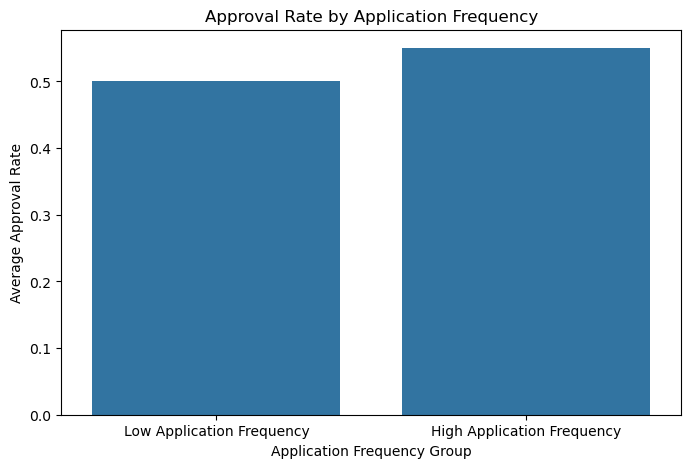

In [157]:
merged_data = application_frequency.merge(
    base_file,
    on='Client_ID',
    how='inner'
)
median_frequency = (
    merged_data['Application_Frequency']
    .median()
)
merged_data['Frequency_Group'] = np.where(
    merged_data['Application_Frequency'] > median_frequency,
    'High Application Frequency',
    'Low Application Frequency'
)

#--Approval Rate Calculation--
merged_data['Approval_Rate'] = (merged_data['Approved']/merged_data['Applied'])

# Handle invalid values
merged_data['Approval_Rate'] = (
    merged_data['Approval_Rate']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)
#--Average Approval Rate by Group--
approval_analysis = (
    merged_data
    .groupby('Frequency_Group')['Approval_Rate']
    .mean()
    .reset_index()
)
approval_analysis['Approval_Rate'] = (
    approval_analysis['Approval_Rate']
    .round(2)
)
print(approval_analysis)

#--Bar Plot--
plt.figure(figsize=(8,5))
sns.barplot(
    data=approval_analysis,
    x='Frequency_Group',
    y='Approval_Rate',
    order=[
        'Low Application Frequency',
        'High Application Frequency'])
plt.title('Approval Rate by Application Frequency')
plt.xlabel('Application Frequency Group')
plt.ylabel('Average Approval Rate')
plt.show()

**Key Insights**
**Data Quality & Integrity Insights**
1. Client-level validation revealed inconsistencies across datasets, including missing client records, duplicate entries, and null values in critical financial columns.
2. Logical consistency checks identified that a small portion of clients had anomalous tradeline or enquiry progression patterns across time periods, indicating possible data recording or aggregation issues.
3. Outlier detection using the IQR method and Winsorization showed that a minority of clients exhibited extremely high tradeline and enquiry activity, which could significantly skew statistical analysis if untreated.
Data cleaning and standardization improved dataset reliability by correcting datatype inconsistencies, handling missing values, and removing invalid negative financial records.


**Credit Behaviour Insights**
1. Most clients were concentrated in the medium tradeline activity segment, indicating moderate credit usage behavior across the customer base.
The distributions of tradelines and enquiries were positively skewed, suggesting that while most customers maintain moderate activity, a small group demonstrates very high credit engagement.
2. Clients with higher tradeline activity generally showed increased loan application frequency, indicating a strong relationship between active credit usage and borrowing behavior.
3. Credit enquiry activity and tradeline activity showed a positive correlation, suggesting that customers actively seeking credit tend to expand their credit exposure over time.


**Loan Approval Insights**
1. Loan approval rates varied significantly across different customer segments based on spending behavior, application frequency, and risk level.
High-frequency loan applicants often demonstrated different approval behavior compared to low-frequency applicants, highlighting potential patterns of repeated borrowing or financial stress.
2. Customers with moderate spending and balanced credit activity typically showed more stable approval behavior compared to extreme high-risk profiles.
3. Approval rate analysis suggested that loan approvals are not solely dependent on spending levels but are influenced by overall credit behavior and engagement patterns.


**Risk Assessment Insights**
1. Clients categorized as high risk based on tradelines, enquiries, and spending behavior demonstrated stronger signs of aggressive credit utilization and borrowing dependency.
2. Credit utilization analysis showed that some clients operate close to maximum credit usage levels, which may indicate elevated repayment risk.
3. Frequent enquiries combined with high tradeline counts can serve as strong indicators of elevated financial exposure and possible future default risk.
4. Segmentation analysis helped distinguish low-risk and highly engaged clients from customers with potentially unstable borrowing behavior.


**Customer Segmentation Insights**
1. Customer segmentation based on tradeline activity, spending behavior, and enquiry patterns successfully identified distinct behavioral groups.
2. Medium-engagement customers formed the largest segment, suggesting an opportunity for targeted lending and retention strategies.
3. Highly engaged customers demonstrated stronger credit activity and higher interaction with financial products, making them suitable candidates for premium financial offerings.
4. Low-engagement customers may require personalized financial education or targeted marketing campaigns to improve product adoption.


**Recommendations**
**Data Management Recommendations**
Implement stricter data validation rules during data collection to reduce missing values, duplicates, and inconsistent financial records.
Introduce automated anomaly detection systems for tradeline and enquiry progression inconsistencies.
Standardize numeric and categorical data formats at the ingestion stage to reduce preprocessing effort.

**Credit Risk Recommendations**
Use tradeline activity, enquiry behavior, and credit utilization as key variables in credit risk scoring models.
Closely monitor customers with:

--high enquiry frequency,
--high credit utilization,
--and excessive tradeline growth,
as these patterns may indicate elevated lending risk.

Introduce early-warning systems for clients exhibiting rapid increases in credit activity.


**Loan Approval Strategy Recommendations**
Build differentiated approval strategies for:
low-risk,
medium-risk,
and high-risk customer groups.
Consider stricter verification and monitoring for high-frequency loan applicants to reduce default exposure.
Improve approval efficiency by leveraging behavioral segmentation rather than relying only on application counts.


**Customer Engagement Recommendations**
Develop personalized financial products for medium and high-engagement customers who demonstrate healthy credit behavior.
Encourage low-engagement customers through customized offers, awareness campaigns, and credit education programs.
Use customer segmentation to improve cross-selling and upselling opportunities for banking products.


**Final Conclusion**
This project successfully demonstrates a complete end-to-end financial data analysis workflow involving data validation, cleaning, exploratory analysis, feature engineering, customer segmentation, and risk assessment. The analysis uncovered meaningful relationships between client credit behavior, spending activity, loan applications, and approval outcomes. The findings can support financial institutions in improving loan approval strategies, enhancing customer profiling, reducing credit risk, and enabling data-driven lending decisions.